In [51]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [52]:
# Məlumatı yükləyirik
df = pd.read_csv(r"C:\Users\user\Downloads\cars (1).csv")

# Təkrar sətirləri silirik
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset ölçüsü: {df.shape}")

Dataset ölçüsü: (653721, 56)


In [53]:
# 1. Lazımsız və təkrar sütunları silirik
cols_to_drop = [
    'id_x', 'id_y', 'car_details_id_x', 'car_details_id_y', 'cars_id',
    'car_rel_url_x', 'car_rel_url_y', 'car_rel_url', 'img_url',
    'phone', 'owner_name', 'vin', 'price_y', 'currency_y'
]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 2. Qiymətləri vahid valyutaya (AZN) gətiririk (Məsələn: 1 USD = 1.7 AZN)
USD_TO_AZN = 1.7
df['price_azn'] = np.where(df['currency_x'] == '$', df['price_x'] * USD_TO_AZN, df['price_x'])

# 3. Mətn şəklində olan rəqəmsal sütunları təmizləyirik
# Yürüş (kilometrage) təmizlənməsi: "270 000 km" -> 270000
if 'Yürüş' in df.columns:
    df['clean_mileage_km'] = (
        df['Yürüş']
        .astype(str)
        .str.replace('km', '', regex=False)
        .str.replace(' ', '', regex=False)
    )
    df['clean_mileage_km'] = pd.to_numeric(df['clean_mileage_km'], errors='coerce')

# Yerlərin sayı təmizlənməsi: "8+" -> 8
if 'Yerlərin sayı' in df.columns:
    df['clean_seats'] = (
        df['Yerlərin sayı']
        .astype(str)
        .str.replace('+', '', regex=False)
    )
    df['clean_seats'] = pd.to_numeric(df['clean_seats'], errors='coerce')

print("Məlumat ön emaldan keçdi. Yekun sütunlar hazırladı.")

Məlumat ön emaldan keçdi. Yekun sütunlar hazırladı.


In [54]:
df.head()

,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,...,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,extra_info,price_azn,clean_mileage_km,clean_seats
0,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.0,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,...,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...,15000.0,270000,5.0
1,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,...,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,Yüngül lehimli disklər* ABS* Kondisioner* Otur...,23700.0,0,5.0
2,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.0,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,...,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...,60520.0,164750,8.0
3,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,...,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...,26700.0,126000,NaN
4,2024-09-13 20:32:19.751157+00,Toyota Prius,10500.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2007, 1.5 L, 354 000 km",2007,...,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,354 000 km,Ön,Bakı,Arxa görüntü kamerası,10500.0,354000,5.0


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653721 entries, 0 to 653720
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   datetime_scrape           653721 non-null  object 
 1   name                      653721 non-null  object 
 2   price_x                   653721 non-null  float64
 3   currency_x                653721 non-null  object 
 4   datetime_product          653721 non-null  object 
 5   city                      653721 non-null  object 
 6   day                       653721 non-null  object 
 7   hour                      653721 non-null  object 
 8   attributes                653721 non-null  object 
 9   production_year           653721 non-null  int64  
 10  engine_displacement_num   653721 non-null  float64
 11  engine_displacement_unit  647933 non-null  object 
 12  kilometrage_num           653721 non-null  int64  
 13  kilometrage_unit          647933 non-null  o

In [56]:
df.describe()

,price_x,production_year,engine_displacement_num,kilometrage_num,views,Buraxılış ili,price_azn,clean_mileage_km,clean_seats
count,653721.000000,653721.000000,653721.000000,6.537210e+05,653721.000000,653721.000000,653721.000000,6.537210e+05,487890.000000
mean,31630.966437,1995.886897,2.221417,1.565231e+05,3740.731827,2013.797752,41102.605933,1.566091e+05,5.142071
std,28679.360855,188.793547,1.266334,1.458949e+05,10299.032842,7.646318,47353.252000,1.458295e+05,0.976479
min,500.000000,0.000000,0.000000,0.000000e+00,12.000000,1938.000000,500.000000,0.000000e+00,1.000000
25%,16800.000000,2009.000000,1.600000,5.502200e+04,432.000000,2009.000000,17200.000000,5.555500e+04,5.000000
50%,25300.000000,2015.000000,2.000000,1.450000e+05,1367.000000,2015.000000,27900.000000,1.450000e+05,5.000000
75%,36800.000000,2019.000000,2.500000,2.223330e+05,3412.000000,2019.000000,47090.000000,2.223330e+05,5.000000
max,940000.000000,2024.000000,120.000000,9.900025e+06,359317.000000,2024.000000,940000.000000,9.900025e+06,8.000000


In [57]:
df.isnull().sum()

datetime_scrape                  0
name                             0
price_x                          0
currency_x                       0
datetime_product                 0
city                             0
day                              0
hour                             0
attributes                       0
production_year                  0
engine_displacement_num          0
engine_displacement_unit      5788
kilometrage_num                  0
kilometrage_unit              5788
barter                      428168
loan                        490381
salon                       460382
spare_parts                 651959
vip                         364780
featured                    489886
datetime                         0
description                  15529
shop_name                   453761
updated                          0
views                            0
Ban növü                         0
Buraxılış ili                    0
Hansı bazar üçün yığılıb    189505
Marka               

**Qruplar üzrə təsviri statistika**

In [58]:
group_columns = [
    "Marka",
    "Şəhər",
    "Ban növü",
    "Sürətlər qutusu",
    "Ötürücü",
    "Rəng",
    "Yeni"
]

# Yalnız mövcud olan sütunları filtrləyirik
valid_group_cols = [col for col in group_columns if col in df.columns]

for col in valid_group_cols:
    print("=" * 80)
    print(f"{col} üzrə təsviri statistika (Qiymət AZN ilə)")
    print("=" * 80)

    # Qruplaşdırıb statistik göstəriciləri hesablayırıq
    stats_df = (
        df.groupby(col)["price_azn"]
        .agg(
            Count="count",
            Mean="mean",
            Median="median",
            Std="std",
            Min="min",
            Max="max",
            Skew="skew",
            Kurtosis=lambda x: x.kurtosis()
        )
        .round(2)
        .sort_values("Count", ascending=False) # Ən çox elanı olan qrupları öndə göstəririk
    )

    print(stats_df.head(15)) # Çox uzun siyahıların qarşısını almaq üçün ilk 15-i göstəririk
    print("\n")

Marka üzrə təsviri statistika (Qiymət AZN ilə)
            Count       Mean   Median       Std     Min       Max  Skew  \
Marka                                                                     
Mercedes    90830   45212.67  25500.0  58292.39   860.0  765943.5  3.92   
Hyundai     85968   28437.85  25400.0  13630.84   700.0  450000.0  2.78   
Toyota      75167   42879.96  36300.0  31857.31  1000.0  257643.5  2.20   
Kia         67029   30588.86  28300.0  13372.95   700.0  250000.0  1.31   
BMW         54432   51134.77  36500.0  45423.61   999.0  450500.0  2.98   
Land Rover  29883  106813.18  80750.0  95252.22  2900.0  706350.0  2.70   
Ford        27159   25211.31  22500.0  16127.87  1100.0  235000.0  5.46   
Nissan      25043   20470.28  16200.0  17543.15   550.0  212330.0  5.76   
LADA (VAZ)  24014    9941.74   7500.0   6971.20   600.0   68000.0  1.30   
Chevrolet   19163   19225.95  16800.0  13068.40  2300.0  195000.0  7.12   
Opel        15023    9893.27  10000.0   3944.33   750

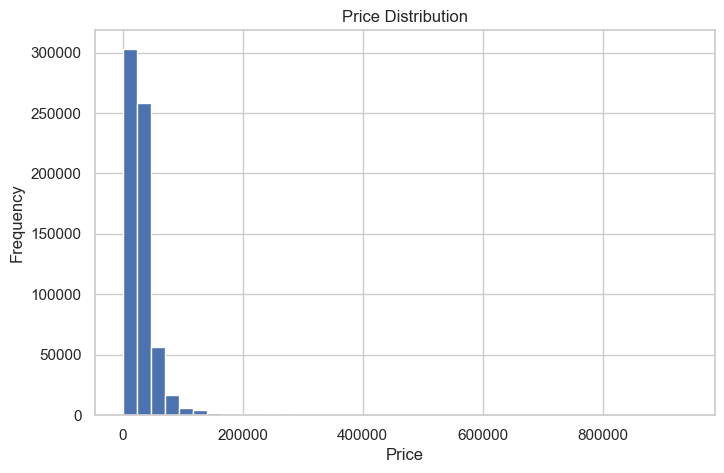

In [59]:
#Paylanma formasını vizuallaşdırırıq

plt.figure(figsize=(8,5))
df["price_x"].hist(bins=40)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

<Figure size 1200x600 with 0 Axes>

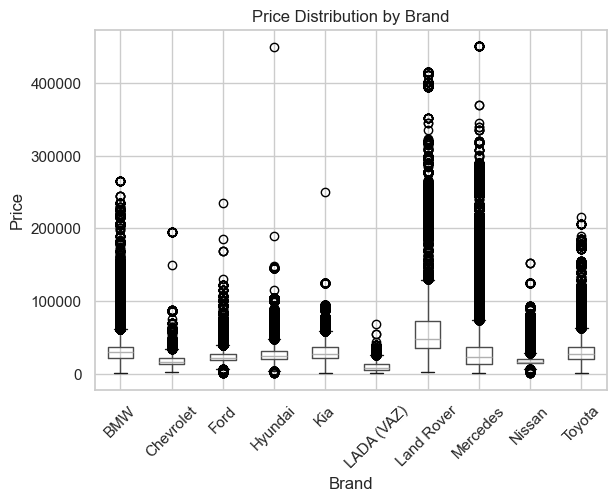

In [60]:
# Marka üzrə qiymət paylanması

top_brands = df["Marka"].value_counts().head(10).index

plt.figure(figsize=(12,6))

df[df["Marka"].isin(top_brands)].boxplot(
    column="price_x",
    by="Marka",
    rot=45
)

plt.title("Price Distribution by Brand")
plt.suptitle("")
plt.xlabel("Brand")
plt.ylabel("Price")

plt.show()

In [61]:
# Bütün numeric sütunların ümumi təsviri statistikası

numeric_cols = df.select_dtypes(include=np.number)

summary = numeric_cols.describe().T

summary["Median"] = numeric_cols.median()
summary["Std"] = numeric_cols.std()
summary["Skewness"] = numeric_cols.skew()
summary["Kurtosis"] = numeric_cols.kurt()

summary = summary.round(2)

print(summary)

                            count       mean        std     min      25%  \
price_x                  653721.0   31630.97   28679.36   500.0  16800.0   
production_year          653721.0    1995.89     188.79     0.0   2009.0   
engine_displacement_num  653721.0       2.22       1.27     0.0      1.6   
kilometrage_num          653721.0  156523.12  145894.86     0.0  55022.0   
views                    653721.0    3740.73   10299.03    12.0    432.0   
Buraxılış ili            653721.0    2013.80       7.65  1938.0   2009.0   
price_azn                653721.0   41102.61   47353.25   500.0  17200.0   
clean_mileage_km         653721.0  156609.07  145829.51     0.0  55555.0   
clean_seats              487890.0       5.14       0.98     1.0      5.0   

                              50%       75%        max    Median        Std  \
price_x                   25300.0   36800.0   940000.0   25300.0   28679.36   
production_year            2015.0    2019.0     2024.0    2015.0     188.79   
en

**2 biznes sualı üçün null/alternativ hipotezlərin hazırlanması**

In [62]:
# Biznes sualı 1 - Avtomobilin markası onun satış qiymətinə təsir edirmi? (One - way ANOVA)

df["price_x"] = pd.to_numeric(df["price_x"], errors="coerce")

# Boş dəyərləri sil
df = df.dropna(subset=["Marka", "price_x"])

# Ən çox elanı olan ilk 10 marka
top_brands = df["Marka"].value_counts().head(10).index

df_top = df[df["Marka"].isin(top_brands)]

# Hər marka üçün qiymətlər
groups = [
    group["price_x"].values
    for _, group in df_top.groupby("Marka")
]

# ANOVA testi
F_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {F_stat:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("H0 rədd edilir.")
    print("Markalar arasında orta qiymətlər statistik olaraq fərqlənir.")
else:
    print("H0 rədd edilmir.")
    print("Markalar arasında statistik fərq müşahidə olunmadı.")

F-statistic: 10053.0417
P-value: 0.000000
H0 rədd edilir.
Markalar arasında orta qiymətlər statistik olaraq fərqlənir.


In [63]:
# Biznes sualı 2 - Yürüş ilə qiymət arasında əlaqə varmı?  (Pearson Correlation)

from scipy.stats import pearsonr

# Numerik formata çevrilməsi
df["price_x"] = pd.to_numeric(df["price_x"], errors="coerce")
df["kilometrage_num"] = pd.to_numeric(df["kilometrage_num"], errors="coerce")

# Null dəyərləri sil
df = df.dropna(subset=["price_x", "kilometrage_num"])

# Pearson testi
corr, p_value = pearsonr(df["kilometrage_num"], df["price_x"])

print(f"Correlation coefficient: {corr:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("H0 rədd edilir.")
    print("Qiymət ilə yürüş arasında statistik əhəmiyyətli əlaqə var.")
else:
    print("H0 rədd edilmir.")
    print("Qiymət ilə yürüş arasında statistik əhəmiyyətli əlaqə yoxdur.")

Correlation coefficient: -0.3208
P-value: 0.000000
H0 rədd edilir.
Qiymət ilə yürüş arasında statistik əhəmiyyətli əlaqə var.


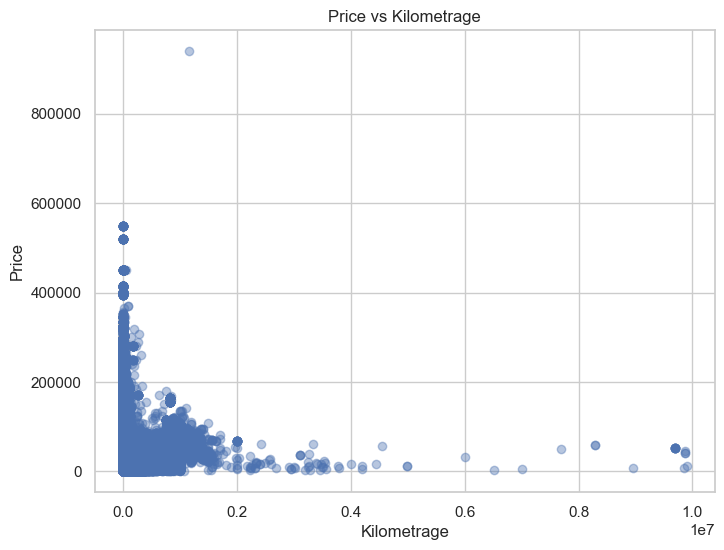

In [64]:
# Əlaqənin vizuallaşdırılması


plt.figure(figsize=(8,6))

plt.scatter(
    df["kilometrage_num"],
    df["price_x"],
    alpha=0.4
)

plt.xlabel("Kilometrage")
plt.ylabel("Price")
plt.title("Price vs Kilometrage")

plt.show()

**Data tipinə uyğun statistik test seçimi və icrası**

In [65]:
# Independent Samples t-test (yuxarıdaki sualları hazırladıqdan sonra statistik testləri tətbiq etdiyim üçün yeni suallar yazacam bu bölümdə)
# Salon avtomobillərinin orta qiyməti fərdi satıcılardan fərqlənirmi?
# H₀: Salon və fərdi satıcıların orta qiymətləri bərabərdir.
# H₁: Salon və fərdi satıcıların orta qiymətləri fərqlidir.

from scipy.stats import ttest_ind


# Qiyməti numerik et
df["price_x"] = pd.to_numeric(df["price_x"], errors="coerce")

# Lazımi sütunlar
df = df.dropna(subset=["price_x", "salon"])

# Salon və fərdi satıcılar
salon = df[df["salon"] == True]["price_x"]
private = df[df["salon"] == False]["price_x"]

# Welch t-test
t_stat, p_value = ttest_ind(salon, private, equal_var=False)

print("T statistic:", round(t_stat,4))
print("P-value:", round(p_value,6))

alpha = 0.05

if p_value < alpha:
    print("H0 rədd edilir.")
    print("Salon və fərdi satıcıların orta qiymətləri statistik olaraq fərqlənir.")
else:
    print("H0 rədd edilmir.")
    print("Statistik fərq yoxdur.")

T statistic: nan
P-value: nan
H0 rədd edilmir.
Statistik fərq yoxdur.


In [66]:
# 2. Chi-Square Test
# Sürətlər qutusu ilə ötürücü sistemi arasında əlaqə varmı?
# H₀: Dəyişənlər müstəqildir.
# H₁: Dəyişənlər arasında əlaqə var.

from scipy.stats import chi2_contingency


df = df.dropna(subset=["Sürətlər qutusu","Ötürücü"])

# Kontingensiya cədvəli
table = pd.crosstab(df["Sürətlər qutusu"],
                    df["Ötürücü"])

print(table)

chi2, p, dof, expected = chi2_contingency(table)

print("\nChi-square:", round(chi2,3))
print("Degrees of Freedom:", dof)
print("P-value:", round(p,6))

alpha = 0.05

if p < alpha:
    print("H0 rədd edilir.")
    print("Sürətlər qutusu ilə ötürücü arasında statistik əlaqə mövcuddur.")
else:
    print("H0 rədd edilmir.")
    print("Statistik əlaqə aşkar edilmədi.")

Ötürücü           Arxa    Tam     Ön
Sürətlər qutusu                     
Avtomat          20199  61628  58496
Mexaniki          4455   3614   4690
Reduktor          2557   8590   4679
Robot              143    653   2326
Variator           134   3147  18028

Chi-square: 21552.238
Degrees of Freedom: 8
P-value: 0.0
H0 rədd edilir.
Sürətlər qutusu ilə ötürücü arasında statistik əlaqə mövcuddur.


In [67]:
# 3. One-Way ANOVA
# Markalara görə orta qiymətlər fərqlənirmi?
# H₀: Bütün markaların orta qiyməti eynidir.
# H₁: Ən azı bir markanın orta qiyməti fərqlidir.

from scipy.stats import f_oneway

df["price_x"] = pd.to_numeric(df["price_x"], errors="coerce")

df = df.dropna(subset=["Marka","price_x"])

# Ən çox elanı olan ilk 10 marka
top10 = df["Marka"].value_counts().head(10).index

df = df[df["Marka"].isin(top10)]

groups = []

for brand in top10:
    groups.append(df[df["Marka"] == brand]["price_x"])

F, p = f_oneway(*groups)

print("F statistic:", round(F,4))
print("P-value:", round(p,6))

alpha = 0.05

if p < alpha:
    print("H0 rədd edilir.")
    print("Markalar arasında orta qiymətlər statistik olaraq fərqlənir.")
else:
    print("H0 rədd edilmir.")
    print("Markalar arasında statistik fərq yoxdur.")

F statistic: 3486.1684
P-value: 0.0
H0 rədd edilir.
Markalar arasında orta qiymətlər statistik olaraq fərqlənir.


**p-dəyərinin və etibar intervalının düzgün interpretasiyası**

In [68]:

from scipy.stats import ttest_ind, t

# Qiyməti numerik formata çevir
df["price_x"] = pd.to_numeric(df["price_x"], errors="coerce")

# Lazımi sütunlar
df = df.dropna(subset=["price_x", "Yeni"])

# Qruplar
new_car = df[df["Yeni"] == "Bəli"]["price_x"]
used_car = df[df["Yeni"] == "Xeyr"]["price_x"]

print("Yeni avtomobil sayı:", len(new_car))
print("İşlənmiş avtomobil sayı:", len(used_car))

# Welch t-test
t_stat, p_value = ttest_ind(new_car, used_car, equal_var=False)

# Orta fərq
mean_diff = new_car.mean() - used_car.mean()

# Standart xəta
var1 = new_car.var(ddof=1)
var2 = used_car.var(ddof=1)

n1 = len(new_car)
n2 = len(used_car)

se = np.sqrt(var1/n1 + var2/n2)

# Welch sərbəstlik dərəcəsi
dfree = ((var1/n1 + var2/n2)**2) / (
    ((var1/n1)**2)/(n1-1) +
    ((var2/n2)**2)/(n2-1)
)

# 95% Confidence Interval
t_critical = t.ppf(0.975, dfree)

ci_low = mean_diff - t_critical * se
ci_high = mean_diff + t_critical * se

print("\n===== Nəticələr =====")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.6f}")
print(f"Mean Difference : {mean_diff:.2f}")
print(f"95% Confidence Interval: ({ci_low:.2f}, {ci_high:.2f})")

Yeni avtomobil sayı: 33296
İşlənmiş avtomobil sayı: 99446

===== Nəticələr =====
T-statistic : 88.1741
P-value     : 0.000000
Mean Difference : 27285.79
95% Confidence Interval: (26679.26, 27892.33)


In [69]:
# 2. Pearson Correlation + Confidence Interval

from scipy.stats import pearsonr

df["price_x"] = pd.to_numeric(df["price_x"], errors="coerce")
df["kilometrage_num"] = pd.to_numeric(df["kilometrage_num"], errors="coerce")

df = df.dropna(subset=["price_x","kilometrage_num"])

r, p = pearsonr(df["kilometrage_num"], df["price_x"])

# Fisher Transformation
n = len(df)

z = np.arctanh(r)
se = 1 / np.sqrt(n - 3)

z_low = z - 1.96 * se
z_high = z + 1.96 * se

ci_low = np.tanh(z_low)
ci_high = np.tanh(z_high)

print(f"Correlation = {r:.4f}")
print(f"P-value = {p:.6f}")
print(f"95% CI = ({ci_low:.3f}, {ci_high:.3f})")

print("\nInterpretation")

if p < 0.05:
    print("• Əlaqə statistik cəhətdən əhəmiyyətlidir.")
    print("• Lakin p-value əlaqənin gücünü göstərmir.")
    print(f"• Əsl korrelyasiyanın 95% ehtimalla {ci_low:.3f} ilə {ci_high:.3f} arasında olduğu gözlənilir.")

    if ci_low > 0 or ci_high < 0:
        print("• Etibar intervalı 0-ı əhatə etmədiyi üçün əlaqə etibarlıdır.")
else:
    print("• Statistik əhəmiyyətli əlaqə aşkar edilmədi.")

Correlation = -0.3839
P-value = 0.000000
95% CI = (-0.389, -0.379)

Interpretation
• Əlaqə statistik cəhətdən əhəmiyyətlidir.
• Lakin p-value əlaqənin gücünü göstərmir.
• Əsl korrelyasiyanın 95% ehtimalla -0.389 ilə -0.379 arasında olduğu gözlənilir.
• Etibar intervalı 0-ı əhatə etmədiyi üçün əlaqə etibarlıdır.


In [70]:
# 3. ANOVA + Eta Squared (Effect Size)

from scipy.stats import f_oneway


df["price_x"] = pd.to_numeric(df["price_x"], errors="coerce")
df = df.dropna(subset=["Marka","price_x"])

top10 = df["Marka"].value_counts().head(10).index
df = df[df["Marka"].isin(top10)]

groups = [group["price_x"].values for _, group in df.groupby("Marka")]

F, p = f_oneway(*groups)

grand_mean = df["price_x"].mean()

ss_between = sum(
    len(g) * (np.mean(g) - grand_mean) ** 2
    for g in groups
)

ss_total = sum(
    (df["price_x"] - grand_mean) ** 2
)

eta_squared = ss_between / ss_total

print(f"F = {F:.4f}")
print(f"P-value = {p:.6f}")
print(f"Eta Squared = {eta_squared:.3f}")

print("\nInterpretation")

if p < 0.05:
    print("• Markalar arasında statistik fərq mövcuddur.")
    print("• Lakin p-value fərqin böyüklüyünü göstərmir.")
    print(f"• Eta Squared = {eta_squared:.3f}, bu qiymət markanın qiymət dəyişkənliyinin hansı hissəsini izah etdiyini göstərir.")
else:
    print("• Statistik fərq aşkar edilmədi.")

F = 3486.1684
P-value = 0.000000
Eta Squared = 0.191

Interpretation
• Markalar arasında statistik fərq mövcuddur.
• Lakin p-value fərqin böyüklüyünü göstərmir.
• Eta Squared = 0.191, bu qiymət markanın qiymət dəyişkənliyinin hansı hissəsini izah etdiyini göstərir.


**Parametrik testdən əvvəl fərziyyələrin yoxlanması**

In [71]:
# 1. Normallığın yoxlanması (Shapiro-Wilk Test)

from scipy.stats import shapiro

df["price_x"] = pd.to_numeric(df["price_x"], errors="coerce")
df = df.dropna(subset=["price_x", "Yeni"])

new_car = df[df["Yeni"] == "Bəli"]["price_x"]
used_car = df[df["Yeni"] == "Xeyr"]["price_x"]

# Maksimum 5000 müşahidə götür
new_sample = new_car.sample(min(5000, len(new_car)), random_state=42)
used_sample = used_car.sample(min(5000, len(used_car)), random_state=42)

stat1, p1 = shapiro(new_sample)
stat2, p2 = shapiro(used_sample)

print("Yeni avtomobillər")
print(f"Statistic = {stat1:.4f}")
print(f"P-value = {p1:.6f}")

print("\nİşlənmiş avtomobillər")
print(f"Statistic = {stat2:.4f}")
print(f"P-value = {p2:.6f}")

Yeni avtomobillər
Statistic = 0.7635
P-value = 0.000000

İşlənmiş avtomobillər
Statistic = 0.5726
P-value = 0.000000


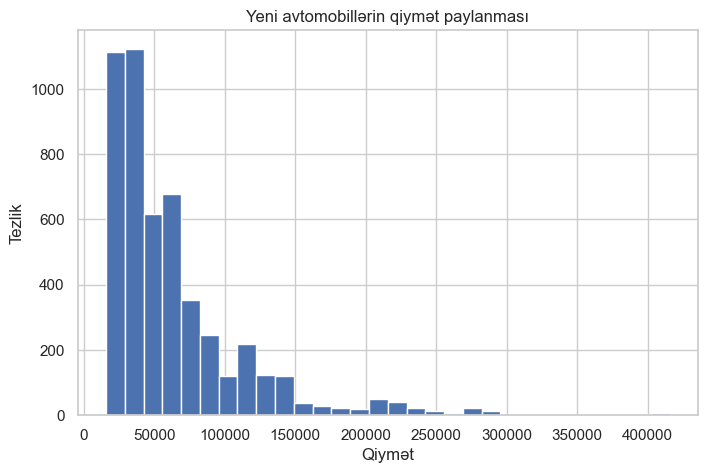

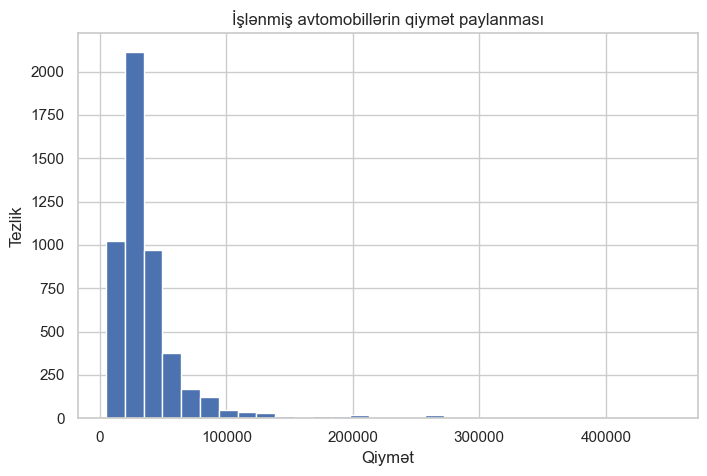

In [72]:
# 2. Histogram

plt.figure(figsize=(8,5))
plt.hist(new_sample, bins=30)
plt.title("Yeni avtomobillərin qiymət paylanması")
plt.xlabel("Qiymət")
plt.ylabel("Tezlik")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(used_sample, bins=30)
plt.title("İşlənmiş avtomobillərin qiymət paylanması")
plt.xlabel("Qiymət")
plt.ylabel("Tezlik")
plt.show()

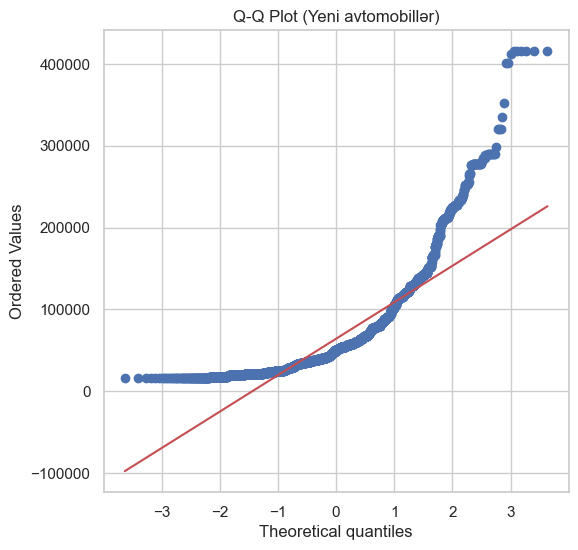

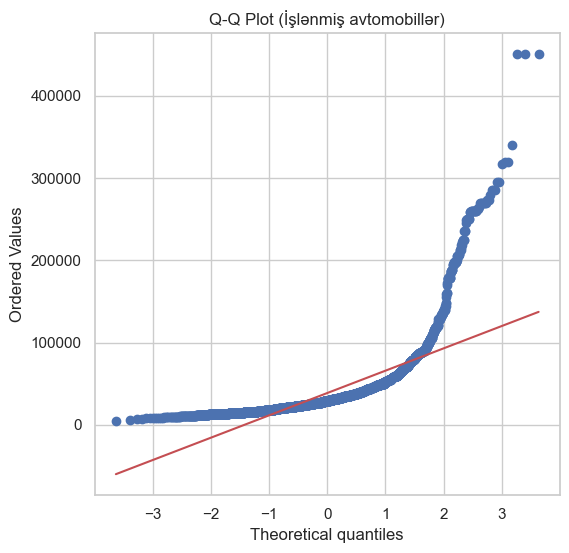

In [73]:
# 3. Q-Q Plot

from scipy.stats import probplot

plt.figure(figsize=(6,6))
probplot(new_sample, dist="norm", plot=plt)
plt.title("Q-Q Plot (Yeni avtomobillər)")
plt.show()

plt.figure(figsize=(6,6))
probplot(used_sample, dist="norm", plot=plt)
plt.title("Q-Q Plot (İşlənmiş avtomobillər)")
plt.show()

In [74]:
# 4. Dispersiya bərabərliyi (Levene Test)

from scipy.stats import levene

stat, p = levene(new_car, used_car)

print(f"Levene Statistic = {stat:.4f}")
print(f"P-value = {p:.6f}")

if p > 0.05:
    print("Dispersiyalar bərabər hesab edilə bilər.")
else:
    print("Dispersiyalar bərabər deyil.")

Levene Statistic = 6128.5983
P-value = 0.000000
Dispersiyalar bərabər deyil.
